# Matplotlib

Basic imports

In [97]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

%matplotlib inline

Hello Matplotlib (OOP style)!

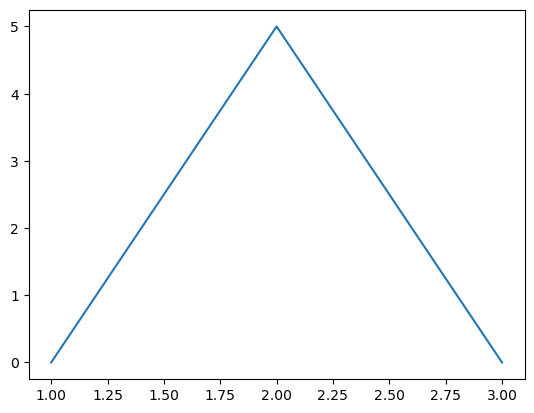

In [98]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [0, 5, 0])

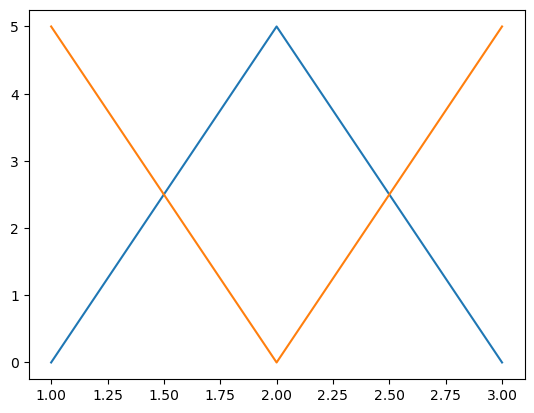

In [ ]:
ax.plot([1, 2, 3], [5, 0, 5])
# plt.show(True) # does not work: it only shows new or closed figures
display(fig) # ask IPython to display the figure!

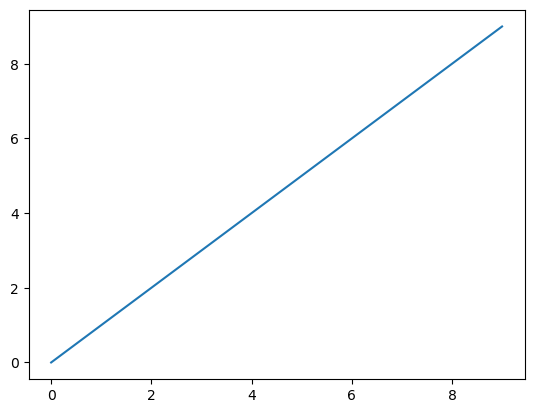

In [100]:
fig, ax = plt.subplots() # default: nrows=1, ncols=1
ax.plot(range(10)) # plots argument as y, using x=range(len(y))
# fig.show()

Hello Matplotlib (pyplot style)!

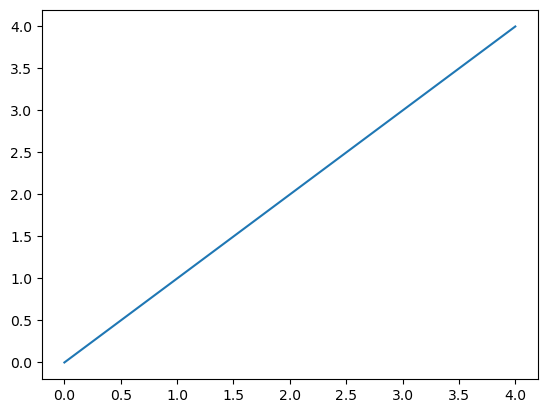

In [101]:
plt.plot(range(5)) # plots argument as y, using x=range(len(y))
# plt.show()

Creating a figure and axes

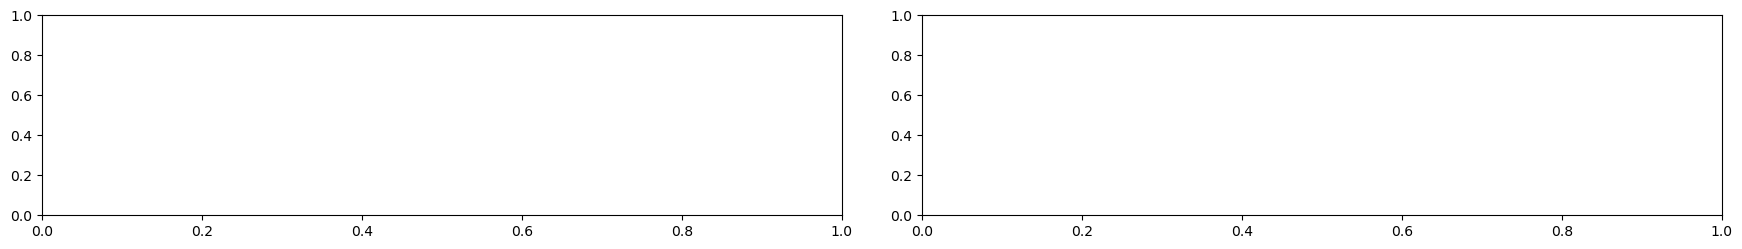

In [102]:
fig = plt.figure(figsize=(8, 2)) # figsize specifies width and height in inches; default figsize=(6.4, 4.8)
ax1 = fig.add_axes((0,0,1,1)) # (left,bottom,width,height) where values are expressed as fraction of figure width and height
ax2 = fig.add_axes((1.1,0,1,1))
#fig.show()

`Figure.subplots` creates a grid of axes in the figure.

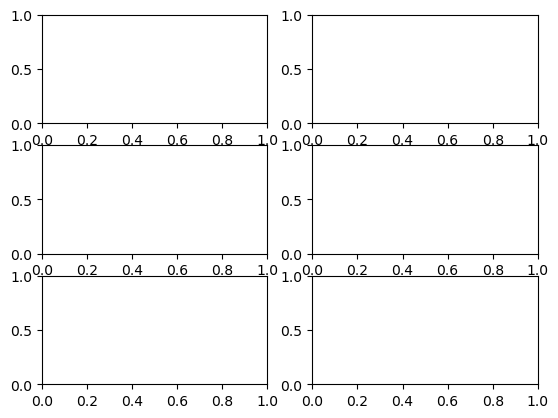

In [103]:
fig = plt.figure()
axes = fig.subplots(nrows = 3, ncols = 2)
#fig.show()

**Adding subplots.** Using `add_subplot(nrows, ncols, index, **kwargs)` with all its three arguments:

* The subplot will take the index position on a grid with `nrows` rows and `ncols` columns. `index` starts at 1 in the upper left corner and increases to the right. `index` can also be a two-tuple specifying the **(first, last)** indices **(1-based, and including last)** of the subplot, e.g., fig.add_subplot(3, 1, (1, 2)) makes a subplot that spans the upper 2/3 of the figure.

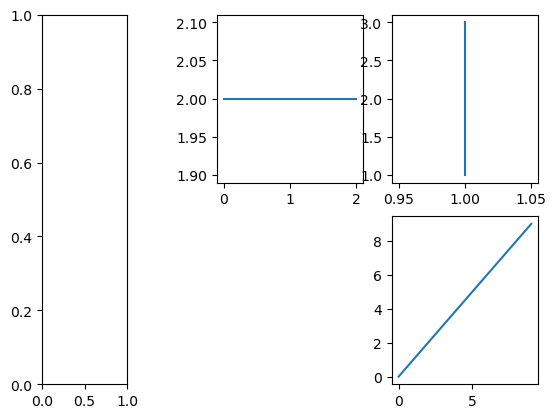

In [104]:
fig = plt.figure()
ax1 = fig.add_subplot(1,5,1) # figure is divided into 1 row and 5 columns, and the axes takes the first cell, i.e. (1,1)
# NB: same as: ax1 = fig.add_subplot(151)
ax2 = fig.add_subplot(2,3,2) # figure is divided into 2 rows and 3 columns, and the axes takes the second cell, i.e. (1,2)
ax2.plot([2,2,2])
ax3 = fig.add_subplot(2,3,3) # figure is divided into 2 rows and 3 columns, and the axes takes the third cell, i.e. (1,3)
ax3.plot([1,1,1], [1,2,3])
ax4 = fig.add_subplot(2,3,6) # figure is divided into 2 rows and 3 columns, and the axes takes the sixth cell, i.e. (2,3)
ax4.plot(range(10))
#fig.show()


The grid of axes create by `Figure.subplots` can share the x and y axes (see arguments `sharex='col'` and `sharey='row'`).

[<Axes: > <Axes: >]


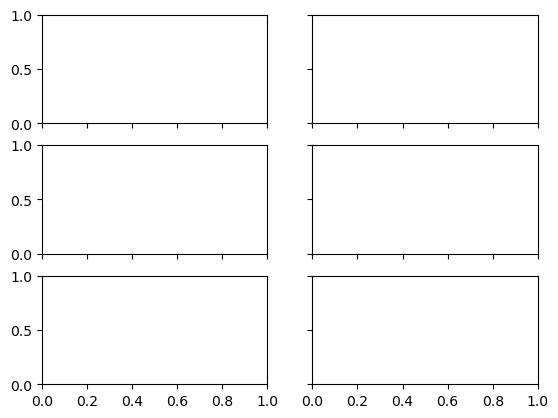

In [105]:
fig = plt.figure()
axrow1, axrow2, axrow3 = fig.subplots(nrows = 3, ncols = 2, sharex='col', sharey='row')
print(axrow1)
#fig.show()

**Axes vs. subplots**: basically, a subplot is an axes. The point is how they are created.
Let's consider `add_axes` vs. `add_subplot`: 

* `add_axes`: The calling signature of add_axes is `add_axes(rect)`, where rect is a list `[x0, y0, width, height]` denoting the lower left point of the new axes in figure coodinates (x0,y0) and its width and height. So the axes is positionned in absolute coordinates on the canvas. 
* `add_subplot`:  It rather allows to specify where the axes should be situated according to a subplot grid. The advantage of this method is that matplotlib takes care of the exact positioning. By default add_subplot(111) would produce an axes positioned at [0.125,0.11,0.775,0.77] or similar, which already leaves enough space around the axes for the title and the (tick)labels. However, this position may also change depending on other elements in the plot, titles set, etc. It can also be adjusted using pyplot.subplots_adjust(...) or pyplot.tight_layout().

/tmp/ipykernel_1149485/1226392307.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # Adjust the padding between and around subplots.


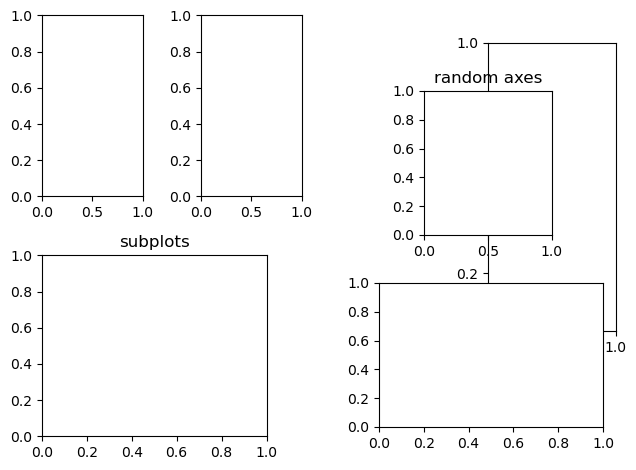

In [106]:
fig = plt.figure()
fig.add_subplot(241)
fig.add_subplot(242)
ax = fig.add_subplot(223)
ax.set_title("subplots")

fig.add_axes([0.77,.3,.2,.6])
ax2 =fig.add_axes([0.67,.5,.2,.3])
fig.add_axes([0.6,.1,.35,.3])
ax2.set_title("random axes")

plt.tight_layout() # Adjust the padding between and around subplots.
#plt.show()

Creating figures with `plt.subplots`

11


<Figure size 640x480 with 0 Axes>

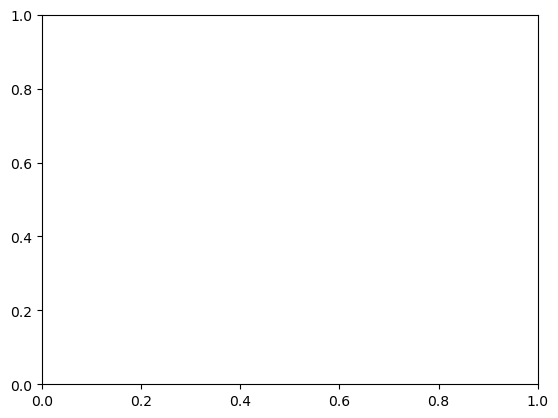

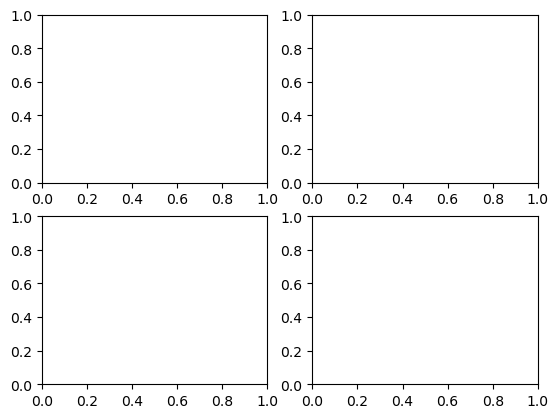

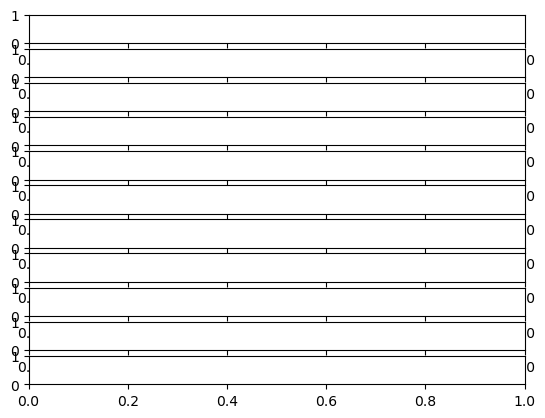

In [107]:
f1 = plt.figure() # empty, with no axes
#f1.show()
f2, axes2 = plt.subplots() # one figure with one axes
#f2.show()
f3, axes3 = plt.subplots(2,2) # one figure with 2x2 axes
#f3.show()
f4, axes4 = plt.subplots(11) # one figure with 11 axes (nrows=11)
print(len(axes4))
#f4.show()

Configuring an `Axes`' properties.

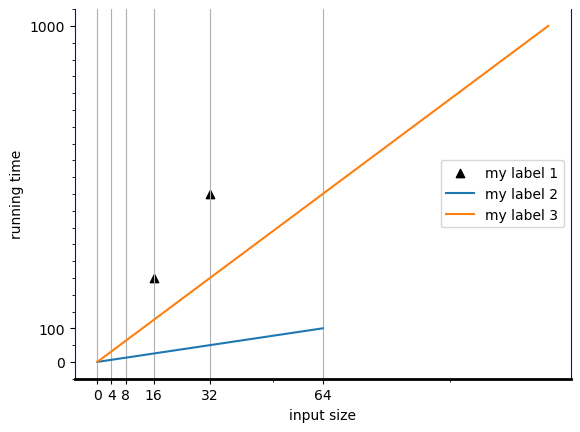

In [108]:
fig, axes = plt.subplots()
axes.set_xlabel("input size")
axes.set_ylabel("running time")
axes.set_xticks([0,2**2,2**3,2**4,2**5,2**6])
axes.set_yticks([0,100,1000])
axes.grid(visible = True, axis='x')
axes.xaxis.set_minor_locator(mpl.ticker.FixedLocator([50,100]))
axes.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(50))
axes.spines['top'].set_visible(False)
axes.spines['bottom'].set_linewidth(2)
axes.spines[['left','right']].set_color('b')
axes.scatter([16,32], [250,500], label="markers", marker="^", color='#000')
line1 = axes.plot([0, 2**6], [0,100], label="line1")
line2 = axes.plot([0, 2**7], [0,1000], label="line2")
l = axes.legend() # automatically detects labels from plotted stuff
l = axes.legend(["my label 1", "my label 2", "my label 3"], loc='center right') # labels existing plot elements
#fig.show()

## Providing `numpy.array` inputs to plotting functions

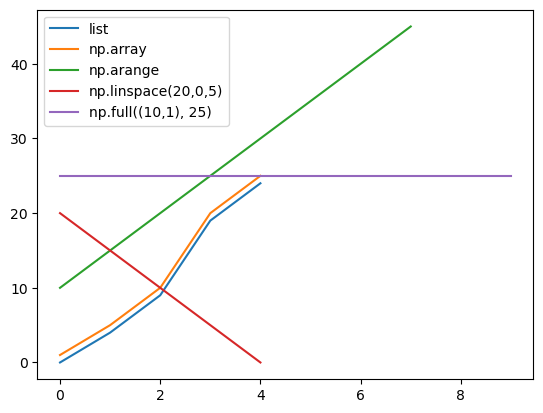

In [109]:
fig, ax = plt.subplots()
ax.plot([0,4,9,19,24], label="list") # plain Python list
ax.plot(np.array([1,5,10,20,25]), label="np.array") # numpy array created from list of values
# numpy array created with np.arange(start,stop,step), i.e. within half-open interval [start, stop)
ax.plot(np.arange(10,50,5), label="np.arange")
# numpy array created with np.linspace(start,stop,num), i.e. num values equally spaced within closed interval [start, stop], i.e. it infers stepsize
ax.plot(np.linspace(20.0, 0.0, num=5), label="np.linspace(20,0,5)")
# numpy array created with np.full(shape,value), i.e. all values are equal to value
ax.plot(np.full((10,1), 25), label="np.full((10,1), 25)")
ax.legend(loc='upper left')
#fig.show()


In [ ]:
# Show all notebook figures
#plt.show()